In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, ConfusionMatrixDisplay, classification_report
)

%matplotlib inline
plt.rcParams['figure.figsize'] = (8, 5)
print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


## Exercise 1 – Load Data and Remove Redundant Columns


In [2]:
import pandas as pd
df = pd.read_csv("titanic.csv")
##balanced 
##df = pd.read_csv("balanced.csv")
print("[1] All columns:", list(df.columns))
print("[2] Shape:", df.shape)
df.head()

[1] All columns: ['Unnamed: 0', 'survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']
[2] Shape: (775, 15)


,Unnamed: 0,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,0,3,male,22.0,1.0,0.0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,1,female,38.0,1.0,0.0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,2,1,3,female,26.0,0.0,0.0,7.9250,S,Third,woman,False,Southampton,yes,True
3,3,1,1,female,35.0,1.0,0.0,53.1000,S,First,woman,False,Southampton,yes,False
4,4,0,3,male,35.0,0.0,0.0,8.0500,S,Third,man,True,Southampton,no,True


In [3]:

df.drop(columns=['alive'], inplace=True)

redundant = ['embark_town', 'who', 'adult_male', 'class']
existing  = [c for c in redundant if c in df.columns]
df.drop(columns=existing, inplace=True)

df.dropna(subset=['survived'], inplace=True)

print("\nRemaining columns:", list(df.columns))
print("Shape after cleanup:", df.shape)


Remaining columns: ['Unnamed: 0', 'survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'alone']
Shape after cleanup: (775, 10)


In [4]:
X = df.drop(columns=['survived'])
y = df['survived']

print(f"Features X : {X.shape}")
print(f"Target   y : {y.shape}")
print("\nTarget distribution:")
print(y.value_counts())

Features X : (775, 9)
Target   y : (775,)

Target distribution:
survived
0    455
1    320
Name: count, dtype: int64


## Exercise 2 – Train-Test Splitting


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y
)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")

X_train : (620, 9)
X_test  : (155, 9)
y_train : (620,)
y_test  : (155,)


In [6]:
print("Class distribution – Training set (normalized):")
print(y_train.value_counts(normalize=True).round(3))

print("\nClass distribution – Test set (normalized):")
print(y_test.value_counts(normalize=True).round(3))

Class distribution – Training set (normalized):
survived
0    0.587
1    0.413
Name: proportion, dtype: float64

Class distribution – Test set (normalized):
survived
0    0.587
1    0.413
Name: proportion, dtype: float64



## Exercise 3 – Encode Categorical Variables & Scale Numerical Features



In [7]:
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

print(f"Categorical columns : {cat_cols}")
print(f"Numerical  columns  : {num_cols}")

Categorical columns : ['sex', 'embarked']
Numerical  columns  : ['Unnamed: 0', 'pclass', 'age', 'sibsp', 'parch', 'fare']


In [8]:
X_train_enc = pd.get_dummies(X_train, columns=cat_cols, drop_first=False)
X_test_enc  = pd.get_dummies(X_test,  columns=cat_cols, drop_first=False)

X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join='left', axis=1, fill_value=0)

X_train_enc.fillna(X_train_enc.median(), inplace=True)
X_test_enc.fillna(X_train_enc.median(),  inplace=True)

print(f"After encoding – X_train : {X_train_enc.shape}")
print(f"After encoding – X_test  : {X_test_enc.shape}")
X_train_enc

After encoding – X_train : (620, 12)
After encoding – X_test  : (155, 12)


,Unnamed: 0,pclass,age,sibsp,parch,fare,alone,sex_female,sex_male,embarked_C,embarked_Q,embarked_S
387,429,3,32.0,0.0,0.0,8.05000,True,False,True,False,False,True
168,179,3,36.0,0.0,0.0,0.00000,True,False,True,False,False,True
589,672,2,58.5,0.0,0.0,10.50000,True,False,True,False,False,True
211,227,3,20.5,0.0,0.0,7.25000,True,False,True,False,False,True
350,383,1,35.0,1.0,0.0,52.00000,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
731,835,1,39.0,1.0,1.0,73.41975,False,True,False,True,False,False
396,439,2,31.0,0.0,0.0,10.50000,True,False,True,False,False,True
719,821,3,27.0,0.0,0.0,8.66250,True,False,True,False,False,True
676,771,3,48.0,0.0,0.0,7.85420,True,False,True,False,False,True


In [9]:
num_cols_enc = [c for c in num_cols if c in X_train_enc.columns]

scaler = StandardScaler()
X_train_enc[num_cols_enc] = scaler.fit_transform(X_train_enc[num_cols_enc])
X_test_enc[num_cols_enc]  = scaler.transform(X_test_enc[num_cols_enc])

print(f"After scaling – X_train : {X_train_enc.shape}")
print(f"After scaling – X_test  : {X_test_enc.shape}")
print("\nFinal columns:", list(X_train_enc.columns))

After scaling – X_train : (620, 12)
After scaling – X_test  : (155, 12)

Final columns: ['Unnamed: 0', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'alone', 'sex_female', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S']


## Exercise 4 – Correlation Analysis (Training Set Only)


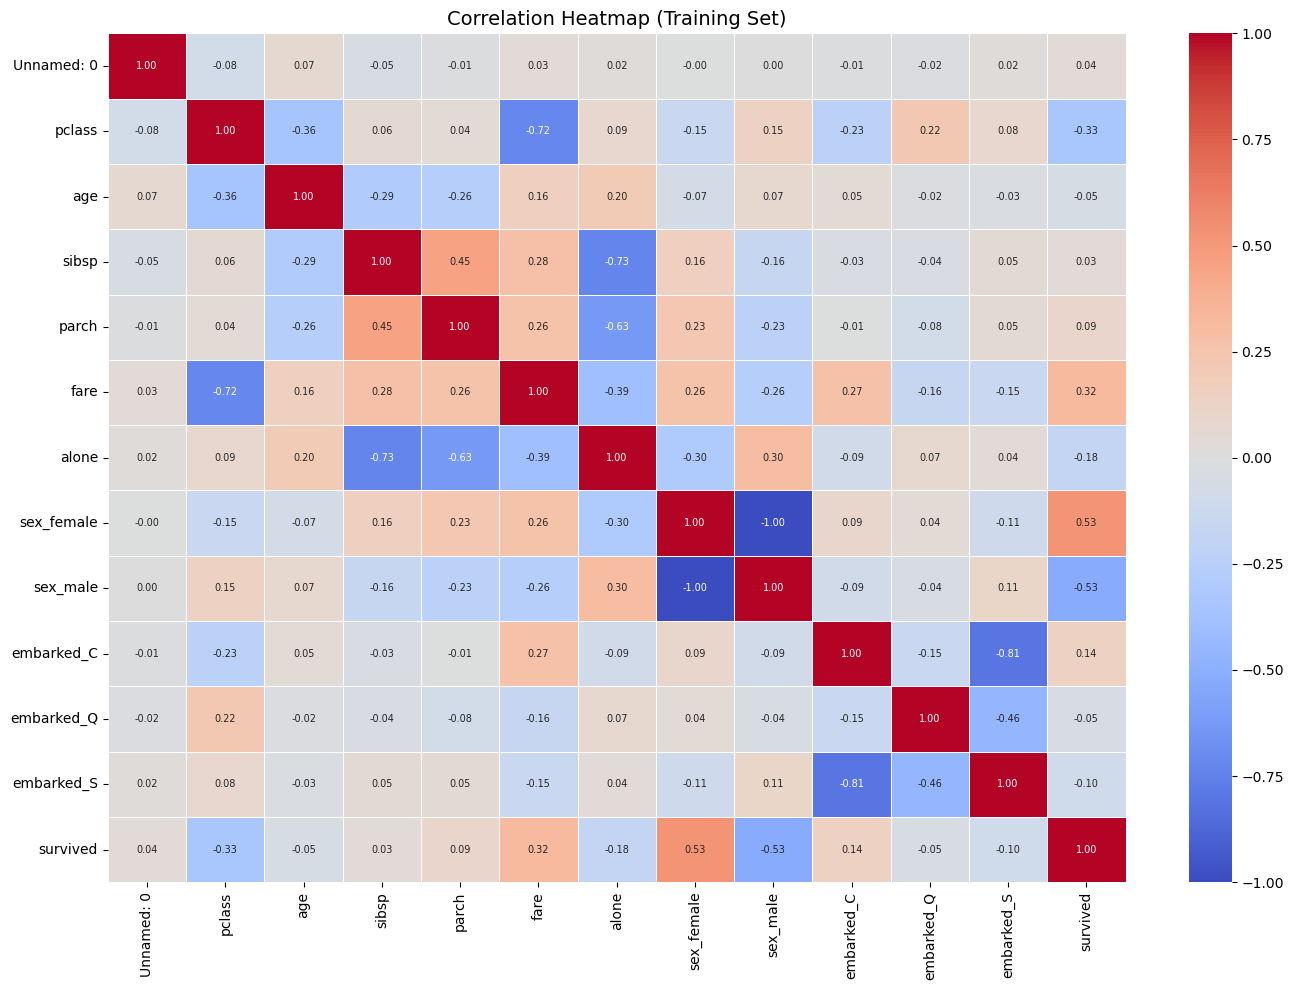

In [10]:
train_df = X_train_enc.copy()
train_df['survived'] = y_train.values

corr_matrix = train_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm',
            linewidths=0.5, annot_kws={"size": 7})
plt.title("Correlation Heatmap (Training Set)", fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
corr_with_target = (
    corr_matrix['survived']
    .drop('survived')
    .abs()
    .sort_values(ascending=False)
)
print("Features ranked by |correlation| with 'survived':")
print(corr_with_target.round(3).to_string())

Features ranked by |correlation| with 'survived':
sex_female    0.530
sex_male      0.530
pclass        0.334
fare          0.316
alone         0.177
embarked_C    0.139
embarked_S    0.097
parch         0.095
age           0.052
embarked_Q    0.047
Unnamed: 0    0.036
sibsp         0.032


In [12]:
print("Feature pairs with |correlation| > 0.8:")
cols = [c for c in corr_matrix.columns if c != 'survived']
found = False
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        val = abs(corr_matrix.loc[cols[i], cols[j]])
        if val > 0.8:
            print(f"  {cols[i]} <-> {cols[j]} : {val:.3f}")
            found = True
if not found:
    print("  None found above 0.8 threshold.")

top3 = corr_with_target.head(3).index.tolist()
print(f"\nTop 3 features most correlated with survival: {top3}")

Feature pairs with |correlation| > 0.8:
  sex_female <-> sex_male : 1.000
  embarked_C <-> embarked_S : 0.810

Top 3 features most correlated with survival: ['sex_female', 'sex_male', 'pclass']


## Exercise 5 – Feature Selection (Training Set Only)


In [13]:
feature_cols = X_train_enc.columns.tolist()
X_tr = X_train_enc.values
X_te = X_test_enc.values

vt = VarianceThreshold(threshold=0.01)
X_tr_vt = vt.fit_transform(X_tr)
X_te_vt = vt.transform(X_te)
kept_vt = [feature_cols[i] for i in range(len(feature_cols)) if vt.get_support()[i]]

print(f"VarianceThreshold: kept {len(kept_vt)} / {len(feature_cols)} features")
print(f"Kept features: {kept_vt}")

VarianceThreshold: kept 12 / 12 features
Kept features: ['Unnamed: 0', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'alone', 'sex_female', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S']


In [14]:
results_kbest = {}
for k in [5, 10, 15]:
    k_actual = min(k, X_tr_vt.shape[1])
    skb = SelectKBest(score_func=f_classif, k=k_actual)
    X_tr_k = skb.fit_transform(X_tr_vt, y_train.values)
    X_te_k = skb.transform(X_te_vt)
    selected = [kept_vt[i] for i in skb.get_support(indices=True)]
    results_kbest[k_actual] = {'selector': skb, 'X_tr': X_tr_k, 'X_te': X_te_k, 'features': selected}
    print(f"SelectKBest k={k_actual}: {selected}")

SelectKBest k=5: ['pclass', 'fare', 'alone', 'sex_female', 'sex_male']
SelectKBest k=10: ['pclass', 'age', 'parch', 'fare', 'alone', 'sex_female', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S']
SelectKBest k=12: ['Unnamed: 0', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'alone', 'sex_female', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S']


In [15]:
k_use = min(10, X_tr_vt.shape[1])

lr_all = LogisticRegression(max_iter=1000, random_state=42)
lr_all.fit(X_tr, y_train)
acc_all = accuracy_score(y_test, lr_all.predict(X_te))

lr_sel = LogisticRegression(max_iter=1000, random_state=42)
lr_sel.fit(results_kbest[k_use]['X_tr'], y_train)
acc_sel = accuracy_score(y_test, lr_sel.predict(results_kbest[k_use]['X_te']))

print(f"LR with ALL features ({len(feature_cols)}) — Test Accuracy: {acc_all:.4f}")
print(f"LR with SelectKBest (k={k_use})       — Test Accuracy: {acc_sel:.4f}")

X_train_final = results_kbest[k_use]['X_tr']
X_test_final  = results_kbest[k_use]['X_te']
sel_features  = results_kbest[k_use]['features']
print(f"\n→ Selected features used for exercises 6-10: {sel_features}")

LR with ALL features (12) — Test Accuracy: 0.7613
LR with SelectKBest (k=10)       — Test Accuracy: 0.7742

→ Selected features used for exercises 6-10: ['pclass', 'age', 'parch', 'fare', 'alone', 'sex_female', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S']


In [16]:
"""best_features = ['sex_male', 'pclass', 'fare', 'alone', 'embarked_S']

X_train_final = X_train_enc[best_features].values
X_test_final  = X_test_enc[best_features].values

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_final, y_train)

acc = accuracy_score(y_test, lr.predict(X_test_final))

print(fLogistic Regression with 5 best features — Test Accuracy: {acc:.4f}")
print(f→ Selected features used: {best_features})

output Logistic Regression with 5 best features — Test Accuracy: 0.7419
→ Selected features used: ['sex_male', 'pclass', 'fare', 'alone', 'embarked_S']"""


'best_features = [\'sex_male\', \'pclass\', \'fare\', \'alone\', \'embarked_S\']\n\nX_train_final = X_train_enc[best_features].values\nX_test_final  = X_test_enc[best_features].values\n\nlr = LogisticRegression(max_iter=1000, random_state=42)\nlr.fit(X_train_final, y_train)\n\nacc = accuracy_score(y_test, lr.predict(X_test_final))\n\nprint(fLogistic Regression with 5 best features — Test Accuracy: {acc:.4f}")\nprint(f→ Selected features used: {best_features})\n\noutput Logistic Regression with 5 best features — Test Accuracy: 0.7419\n→ Selected features used: [\'sex_male\', \'pclass\', \'fare\', \'alone\', \'embarked_S\']'


## Exercise 6 – Baseline Model: Logistic Regression



In [17]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_final, y_train)

y_pred_lr = lr.predict(X_test_final)
y_prob_lr = lr.predict_proba(X_test_final)[:, 1]

acc_lr  = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr  = recall_score(y_test, y_pred_lr)
f1_lr   = f1_score(y_test, y_pred_lr)
auc_lr  = roc_auc_score(y_test, y_prob_lr)

print(f"Accuracy  : {acc_lr:.4f}")
print(f"Precision : {prec_lr:.4f}")
print(f"Recall    : {rec_lr:.4f}")
print(f"F1-score  : {f1_lr:.4f}")
print(f"ROC-AUC   : {auc_lr:.4f}")

Accuracy  : 0.7742
Precision : 0.7458
Recall    : 0.6875
F1-score  : 0.7154
ROC-AUC   : 0.8419


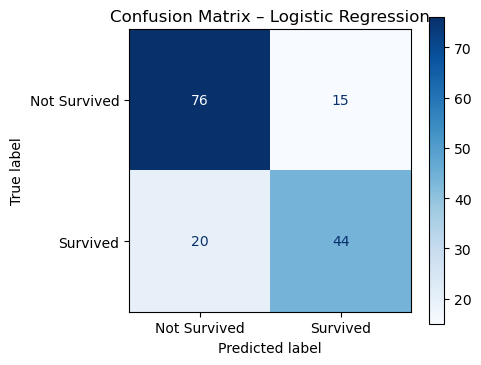

In [18]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=['Not Survived', 'Survived'],
    cmap='Blues', ax=ax
)
plt.title("Confusion Matrix – Logistic Regression")
plt.tight_layout()
plt.show()

In [19]:
print(classification_report(y_test, y_pred_lr, target_names=['Not Survived', 'Survived']))

              precision    recall  f1-score   support

Not Survived       0.79      0.84      0.81        91
    Survived       0.75      0.69      0.72        64

    accuracy                           0.77       155
   macro avg       0.77      0.76      0.76       155
weighted avg       0.77      0.77      0.77       155



## Exercise 7 – Compare Several Models



In [20]:
models = {
    'LogisticRegression': lr,   
    'KNN'               : KNeighborsClassifier(),
    'DecisionTree'      : DecisionTreeClassifier(random_state=42, max_depth=5),
    'RandomForest'      : RandomForestClassifier(random_state=42, n_estimators=100),
}

results = {}
for name, model in models.items():
    if name != 'LogisticRegression':
        model.fit(X_train_final, y_train)
    yp  = model.predict(X_test_final)
    ypr = model.predict_proba(X_test_final)[:, 1]
    results[name] = {
        'Accuracy' : round(accuracy_score(y_test, yp),  4),
        'Precision': round(precision_score(y_test, yp), 4),
        'Recall'   : round(recall_score(y_test, yp),    4),
        'F1'       : round(f1_score(y_test, yp),        4),
        'ROC-AUC'  : round(roc_auc_score(y_test, ypr),  4),
    }

results_df = pd.DataFrame(results).T
print("Model Comparison Table:")
results_df

Model Comparison Table:


,Accuracy,Precision,Recall,F1,ROC-AUC
LogisticRegression,0.7742,0.7458,0.6875,0.7154,0.8419
KNN,0.7871,0.7818,0.6719,0.7227,0.8292
DecisionTree,0.8000,0.7797,0.7188,0.7480,0.8536
RandomForest,0.8387,0.8421,0.7500,0.7934,0.8541


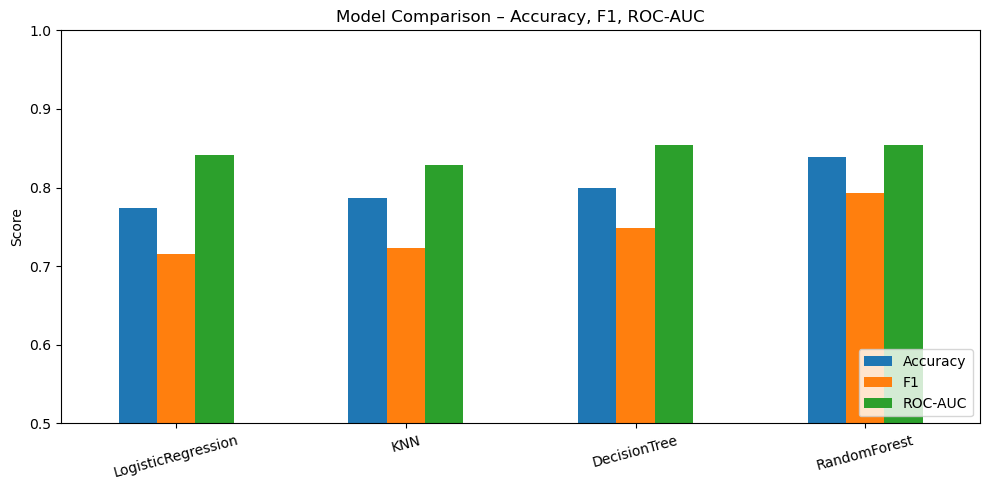

Best by F1-score : RandomForest  (0.7934)
Best by ROC-AUC  : RandomForest (0.8541)


In [21]:
results_df[['Accuracy', 'F1', 'ROC-AUC']].plot(kind='bar', rot=15, figsize=(10, 5))
plt.title("Model Comparison – Accuracy, F1, ROC-AUC")
plt.ylabel("Score")
plt.ylim(0.5, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

best_f1  = results_df['F1'].idxmax()
best_auc = results_df['ROC-AUC'].idxmax()
print(f"Best by F1-score : {best_f1}  ({results_df.loc[best_f1,'F1']})")
print(f"Best by ROC-AUC  : {best_auc} ({results_df.loc[best_auc,'ROC-AUC']})")


## Exercise 8 – Cross-Validation (Training Set Only)



In [22]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_final, y_train,
    cv=cv, scoring='accuracy'
)

print(f"CV scores (5 folds): {np.round(cv_scores, 4)}")
print(f"Mean CV accuracy   : {cv_scores.mean():.4f}")
print(f"Std  CV accuracy   : {cv_scores.std():.4f}")
print(f"Test accuracy (Ex6): {acc_lr:.4f}")

CV scores (5 folds): [0.7903 0.7419 0.7742 0.7177 0.7742]
Mean CV accuracy   : 0.7597
Std  CV accuracy   : 0.0262
Test accuracy (Ex6): 0.7742


### 📝 Why is cross-validation important?

- A **single train/test split** can be lucky or unlucky depending on how data was split.  
- CV **averages performance over 5 folds** → lower variance, more reliable estimate.  
- You must **never CV on the full dataset before splitting**: the test set must remain completely unseen until the final evaluation step.

## Exercise 9 – Overfitting & Underfitting Analysis



In [23]:
lr_train_acc = accuracy_score(y_train, lr.predict(X_train_final))
lr_cv_acc    = cross_val_score(lr, X_train_final, y_train, cv=5, scoring='accuracy').mean()

print(f"Logistic Regression | Train: {lr_train_acc:.4f} | CV: {lr_cv_acc:.4f}")
gap = lr_train_acc - lr_cv_acc
if gap > 0.05:
    print("→ Possible OVERFITTING (train >> CV)")
elif lr_train_acc < 0.75:
    print("→ Possible UNDERFITTING (train accuracy low)")
else:
    print("→ Model is well-balanced")

Logistic Regression | Train: 0.7806 | CV: 0.7645
→ Model is well-balanced


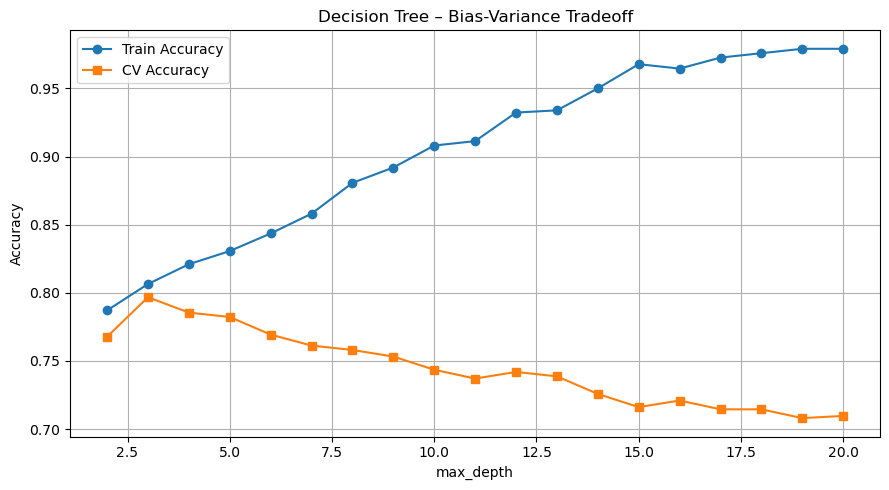

Best max_depth (highest CV acc): 3 → CV = 0.7968


In [24]:
depths   = range(2, 21)
dt_train = []
dt_cv    = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train_final, y_train)
    dt_train.append(accuracy_score(y_train, dt.predict(X_train_final)))
    dt_cv.append(cross_val_score(dt, X_train_final, y_train, cv=5, scoring='accuracy').mean())

plt.figure(figsize=(9, 5))
plt.plot(depths, dt_train, label='Train Accuracy', marker='o')
plt.plot(depths, dt_cv,    label='CV Accuracy',    marker='s')
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree – Bias-Variance Tradeoff")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

best_depth = list(depths)[np.argmax(dt_cv)]
print(f"Best max_depth (highest CV acc): {best_depth} → CV = {max(dt_cv):.4f}")

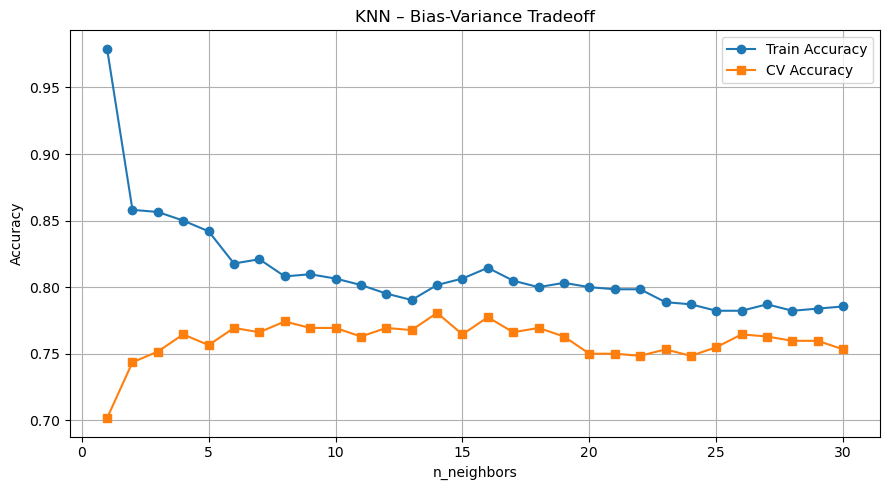

Best n_neighbors (highest CV acc): 14 → CV = 0.7806


In [25]:
neighbors = range(1, 31)
knn_train = []
knn_cv    = []

for k in neighbors:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_final, y_train)
    knn_train.append(accuracy_score(y_train, knn.predict(X_train_final)))
    knn_cv.append(cross_val_score(knn, X_train_final, y_train, cv=5, scoring='accuracy').mean())

plt.figure(figsize=(9, 5))
plt.plot(neighbors, knn_train, label='Train Accuracy', marker='o')
plt.plot(neighbors, knn_cv,    label='CV Accuracy',    marker='s')
plt.xlabel("n_neighbors")
plt.ylabel("Accuracy")
plt.title("KNN – Bias-Variance Tradeoff")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

best_k = list(neighbors)[np.argmax(knn_cv)]
print(f"Best n_neighbors (highest CV acc): {best_k} → CV = {max(knn_cv):.4f}")

In [26]:
dt_best = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt_best.fit(X_train_final, y_train)

print(f"Best Decision Tree (max_depth={best_depth}) — Final TEST SET evaluation:")
print(f"  Accuracy : {accuracy_score(y_test, dt_best.predict(X_test_final)):.4f}")
print(f"  F1-score : {f1_score(y_test, dt_best.predict(X_test_final)):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, dt_best.predict_proba(X_test_final)[:,1]):.4f}")

Best Decision Tree (max_depth=3) — Final TEST SET evaluation:
  Accuracy : 0.7871
  F1-score : 0.7130
  ROC-AUC  : 0.8529



## Exercise 10 – Hyperparameter Tuning with GridSearchCV



In [27]:
param_grid = {
    'n_estimators'    : [50, 100, 200],
    'max_depth'       : [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
}

print("Running GridSearchCV (this may take ~30 seconds) ...")
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train_final, y_train)

print(f"\nBest parameters   : {grid_search.best_params_}")
print(f"Best CV ROC-AUC   : {grid_search.best_score_:.4f}")

Running GridSearchCV (this may take ~30 seconds) ...

Best parameters   : {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
Best CV ROC-AUC   : 0.8383


In [28]:
best_rf = grid_search.best_estimator_

rf_default = RandomForestClassifier(random_state=42, n_estimators=100)
rf_default.fit(X_train_final, y_train)

rows = []
for label, model in [("Default RF", rf_default), ("Tuned RF", best_rf)]:
    yp  = model.predict(X_test_final)
    ypr = model.predict_proba(X_test_final)[:, 1]
    rows.append({
        'Model'    : label,
        'Accuracy' : round(accuracy_score(y_test, yp),  4),
        'F1-score' : round(f1_score(y_test, yp),        4),
        'ROC-AUC'  : round(roc_auc_score(y_test, ypr),  4),
    })

comparison = pd.DataFrame(rows).set_index('Model')
print("Before vs After Tuning (Test Set):")
comparison

Before vs After Tuning (Test Set):


,Accuracy,F1-score,ROC-AUC
Model,,,
Default RF,0.8387,0.7934,0.8541
Tuned RF,0.8194,0.7544,0.8568
